# Pyro SAI — Task 2: Evaporative demand (VPD) under G6-1.5K SAI

**Question:** can SAI-induced cooling lower evaporative demand enough, by reducing the saturation vapour pressure, to decouple fire risk from SAI-induced precipitation deficits? Where does it fail to?

**Method (per model):**
1. Daily **VPD** = e_s(T)·(1 − RH/100). This uses Sonntag (1990) saturation vapour pressure over water, the xclim default, with daily-mean `tas` and `hurs`. Alternatives are `VPD_METHOD="max"` (tasmax with min RH, an afternoon-peak proxy) and `"huss"` (e_s(tas) − e(huss, ps)).
2. For each model: fire-season mean VPD, P95-VPD exceedance days (P95 pooled over SSP2-4.5 target-period members, as in Task 1), and longest spells. The fire season is taken from Task 1, so that FWI and VPD are compared over the same months.
3. **Decomposition** of the G6 − SSP2-4.5 VPD change into a **thermodynamic (temperature) term** and a **humidity (RH) term**. This uses the delta method on SSP2-4.5 daily weather, with monthly climatological ΔT and ΔRH applied one at a time.
4. **Risk-offset classification** combines the sign of Δ fire-season VPD, Δ fire-season precipitation and (from Task 1) Δ fire-season FWI. It separates *risk-offset zones* (cooling wins) from *fire-weather-paradox zones* (drying wins).
5. Welch t-test with FDR, multi-model agreement, and AR6 regional statistics.

**Inputs:** the daily inputs staged by Task 1 (`WORK_ROOT/inputs/...`) are reused, so no NetCDF is re-read. `task1_<model>_summary.nc` supplies the fire season and ΔFWI. **Run Task 1 first.**
**Outputs:** `task2_<model>_summary.nc`, `task2_multimodel_1deg.nc`, `task2_AR6_regional_stats.csv`, and figures in `pyrosai_output/figures/`.

In [1]:
import os, sys, json, warnings, subprocess, time
for pkg, pipname in (("xclim", "xclim"), ("regionmask", "regionmask"), ("netCDF4", "netCDF4")):
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", pipname])
import numpy as np
import pandas as pd
import xarray as xr
import dask
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import xclim, regionmask

sys.path.insert(0, os.getcwd())
import pyrosai as P

warnings.filterwarnings("ignore", category=RuntimeWarning)
xr.set_options(keep_attrs=True)
print({m.__name__: m.__version__ for m in (np, pd, xr, dask, xclim, regionmask)})

{'numpy': '2.0.2', 'pandas': '2.2.3', 'xarray': '2025.1.1', 'dask': '2025.1.0', 'xclim': '0.54.0', 'regionmask': '0.13.0'}


## Configuration
Keep `WORK_ROOT`, `STAGE_INPUTS`, `SPACE_CHUNK`, `BBOX` and the periods **identical to Task 1**, so that the staged inputs are found and reused.

In [2]:
CATALOG_PATH    = "pyrosai_catalog.json"
WORK_ROOT       = "s3://reflective-persistent-prod/<username>/pyrosai"
STORAGE_OPTIONS = None
OUT_DIR         = "./pyrosai_output"

MODELS          = None
MAX_MEMBERS     = 3
TARGET_PERIOD   = P.TARGET_PERIOD
ASSESS_PERIOD   = P.ASSESS_PERIOD
BBOX            = None
STAGE_INPUTS    = True
SPACE_CHUNK     = 48

VPD_METHOD      = "mean"     # "mean": tas + hurs | "max": tasmax + hursmin (or hurs) | "huss": tas + huss + ps
P95             = 0.95
ALPHA_FDR       = 0.10
COMMON_RES      = 1.0
FOCUS_REGIONS   = P.FOCUS_REGIONS
USE_TASK1       = True       # fire season + dFWI from task1_<model>_summary.nc (else VPD-based fire season)
USE_DASK_CLUSTER = True
OVERWRITE_METRICS = False

# ---- personal overrides: put your edits in local_config.py (survives notebook updates) ----
if os.path.exists("local_config.py"):
    exec(open("local_config.py").read())
    print("applied local_config.py")

if os.environ.get("PYROSAI_TEST") == "1":
    CATALOG_PATH, WORK_ROOT, OUT_DIR = os.environ["PYROSAI_CATALOG"], "./test_work", "./test_output"
    SPACE_CHUNK, USE_DASK_CLUSTER = 8, False
assert "<username>" not in WORK_ROOT, "Set WORK_ROOT to your persistent-prod prefix (or a local folder) first"

FIG_DIR = os.path.join(OUT_DIR, "figures")
FIG_DPI = 300   # PNG resolution; a vector PDF is saved alongside each PNG; os.makedirs(FIG_DIR, exist_ok=True)
# must match Task 1 so the same staged stores are reused
INPUT_VARS = ["tasmax", "hursmin", "hurs", "sfcWind", "pr", "tas"]
if VPD_METHOD == "huss":
    INPUT_VARS += ["huss", "ps"]
REQUIRED = {"mean": ["tas", "hurs", "pr"], "max": ["tasmax", "hurs", "pr"], "huss": ["tas", "huss", "ps", "pr"]}[VPD_METHOD]
RUNS = {"target": ("ssp245", TARGET_PERIOD), "ssp245": ("ssp245", ASSESS_PERIOD),
        "G6-1.5K-SAI": ("G6-1.5K-SAI", ASSESS_PERIOD), "G6-1.5K-HiLLA": ("G6-1.5K-HiLLA", ASSESS_PERIOD)}
G6 = ["G6-1.5K-SAI", "G6-1.5K-HiLLA"]

applied local_config.py


In [3]:
if USE_DASK_CLUSTER:
    from dask.distributed import LocalCluster, Client
    cluster = LocalCluster(n_workers=2, threads_per_worker=2, memory_limit="10GiB")   # 20 of 30 GB: leaves room for this kernel (the server is killed if all 30 GB are used)
    client = Client(cluster); print("Dask dashboard:", client.dashboard_link)

catalog = P.apply_known_issues(P.load_catalog(CATALOG_PATH))   # drops known-bad variables (see pyrosai.KNOWN_BAD_VARIABLES)
ws = P.Workspace(catalog, WORK_ROOT, STORAGE_OPTIONS, SPACE_CHUNK, STAGE_INPUTS, BBOX)
P.prepare_wind_corrections(ws, MODELS or [m for m in catalog if not m.startswith("_")], f"{OUT_DIR}/metrics{ws.tag}")
P.prepare_wind_climatology(ws, MODELS or [m for m in catalog if not m.startswith("_")], f"{OUT_DIR}/metrics{ws.tag}")
models = MODELS or ws.models(REQUIRED)
members = {m: {s: ws.members(m, s, REQUIRED, MAX_MEMBERS) for s in P.SCENARIOS} for m in models}
models = P.drop_incomplete(ws, models, members, RUNS, INPUT_VARS)   # same members as Task 1
print("Models ready for Task 2:", models)
for m in models:
    print(f"  {m}: " + ", ".join(f"{s}={members[m][s]}" for s in P.SCENARIOS))

Dask dashboard: /user/savvyscientist/proxy/8787/status
[catalog] merged 4 extra entries from pyrosai_catalog_extra.json


[catalog] CESM2-WACCM: ignored 298 land/ocean/ice-model file(s) (e.g. CLM LDAY/LMON)


[known issue] MIROC-ES2H: removed 'sfcWind' from 6 member(s) - MIROC-ES2H 'sfcWind' files contain a radiative flux (units W/m**2, mean ~160-200), not wind speed (found 2026-10-01)


[wind] MIROC-ES2H: FWI wind = SSP2-4.5 day-of-year climatology of hypot(uas,vas) in ALL scenarios


[wind] UKESM1-1: no member has sfcWind+uas+vas; wind from uas/vas in ALL scenarios (consistent; absolute speeds biased low)


[skip] UKESM1-1/ssp245/r2i1p1f1: inputs miss or have incomplete years [2020, 2021, 2022, 2025, 2026, 2030, 2035] - member dropped from ssp245


Models ready for Task 2: ['CESM2-WACCM', 'MIROC-ES2H', 'UKESM1-1']
  CESM2-WACCM: ssp245=['r1i1p1f1', 'r2i1p1f1', 'r3i1p1f1'], G6-1.5K-SAI=['r1', 'r2', 'r3'], G6-1.5K-HiLLA=['r1', 'r2', 'r3']
  MIROC-ES2H: ssp245=['r1', 'r2', 'r3'], G6-1.5K-SAI=['r1', 'r2', 'r3'], G6-1.5K-HiLLA=['r1', 'r2', 'r3']
  UKESM1-1: ssp245=['r12i1p1f1', 'r3i1p1f1'], G6-1.5K-SAI=['r12i1p1f2', 'r2i1p1f2', 'r3i1p1f2'], G6-1.5K-HiLLA=['r12i1p1f2', 'r2i1p1f2', 'r3i1p1f2']


## 1. Daily VPD and per-member metrics
For each model, run and member, this computes: P95-VPD exceedance days and spells, monthly VPD climatology, monthly time series of VPD and precipitation (for fire-season means per year), and monthly climatologies of `tas` and `hurs` (for the decomposition). Results are cached in `OUT_DIR/metrics/`.

In [4]:
def daily_vpd(ds):
    if VPD_METHOD == "mean":
        return P.vpd_from_rh(ds["tas"], ds["hurs"])
    if VPD_METHOD == "max":
        return P.vpd_from_rh(ds["tasmax"], ds["hursmin"] if "hursmin" in ds else ds["hurs"])
    return P.vpd_from_huss(ds["tas"], ds["huss"], ds["ps"])

def run_inputs(m, scen, mem, years):
    yrs_in = (years[0] - P.SPINUP_YEARS, years[1])          # same store as Task 1
    ds = ws.inputs(m, scen, mem, yrs_in, INPUT_VARS)
    return ds.sel(time=slice(str(years[0]), str(years[1])))

vpd = {m: {run: {mem: daily_vpd(run_inputs(m, scen, mem, yrs)) for mem in members[m][scen]}
           for run, (scen, yrs) in RUNS.items()} for m in models}

thr, metrics = {}, {m: {} for m in models}
for m in models:
    thr[m] = P.cached_netcdf(f"{OUT_DIR}/metrics{ws.tag}/{m}/vpd_{VPD_METHOD}_p95_threshold.nc",
                             lambda: P.pooled_quantile(list(vpd[m]["target"].values()), P95, SPACE_CHUNK)
                             .compute().to_dataset(name="p95"), OVERWRITE_METRICS)["p95"]
    for run, (scen, yrs) in RUNS.items():
        per = []
        for mem in members[m][scen]:
            def calc():
                ds = run_inputs(m, scen, mem, yrs)
                v = vpd[m][run][mem]
                mt = P.exceedance_metrics(v, thr[m], None, spells=True)
                mt["vpd_monthly"] = v.resample(time="MS").mean()
                mt["pr_monthly"] = ds["pr"].resample(time="MS").mean() * 86400.0     # mm/day
                mt["tas_mm"] = P.monthly_climatology(ds["tas"])
                mt["hurs_mm"] = P.monthly_climatology(ds["hurs"])
                return mt.compute()
            per.append(P.cached_netcdf(f"{OUT_DIR}/metrics{ws.tag}/{m}/vpd_{VPD_METHOD}_{run}_{mem}.nc", calc, OVERWRITE_METRICS))
        # monthly series have different time labels per run; keep a common 'time' per run
        metrics[m][run] = P.stack_members(per, members[m][scen])
    P.log(f"[VPD metrics] {m} done")

[VPD metrics] CESM2-WACCM done


[VPD metrics] MIROC-ES2H done


[VPD metrics] UKESM1-1 done


### Sanity checks
The target period should average about 5% of days above P95. VPD should be non-negative, and fire-season means of more than about 6 kPa would indicate a unit problem.

In [5]:
rows = []
for m in models:
    land = P.land_mask(thr[m].lon, thr[m].lat); w = np.cos(np.deg2rad(thr[m].lat))
    ndays = pd.Series(vpd[m]["target"][members[m]["ssp245"][0]].time.dt.year.values).value_counts().median()
    r = {"model": m, "expected P95 days/yr": round((1 - P95) * ndays, 2)}
    for run in RUNS:
        r[f"{run} P95 days/yr"] = float(metrics[m][run]["days_p95"].mean(["member", "year"]).where(land).weighted(w).mean())
        r[f"{run} mean VPD (kPa, land)"] = float(metrics[m][run]["mean"].mean("member").where(land).weighted(w).mean())
    r["max member-mean VPD (kPa)"] = float(metrics[m]["target"]["mean"].mean("member").where(land).max())
    rows.append(r)
chk = pd.DataFrame(rows).set_index("model").T; display(chk.round(3))
for m in models:
    ok = abs(chk.loc["target P95 days/yr", m] - chk.loc["expected P95 days/yr", m]) < 0.5
    print(("[OK] " if ok else "[CHECK] ") + f"{m}: target exceedance {chk.loc['target P95 days/yr', m]:.2f}")
    if chk.loc["max member-mean VPD (kPa)", m] > 6:
        print(f"[CHECK] {m}: very high VPD - check temperature / humidity units")

model,CESM2-WACCM,MIROC-ES2H,UKESM1-1
expected P95 days/yr,18.250,18.250,18.000
target P95 days/yr,18.250,18.267,18.000
"target mean VPD (kPa, land)",1.078,1.182,1.132
ssp245 P95 days/yr,34.428,29.539,40.929
"ssp245 mean VPD (kPa, land)",1.203,1.286,1.317
G6-1.5K-SAI P95 days/yr,19.813,17.447,13.879
"G6-1.5K-SAI mean VPD (kPa, land)",1.090,1.165,1.102
G6-1.5K-HiLLA P95 days/yr,19.825,17.675,18.590
"G6-1.5K-HiLLA mean VPD (kPa, land)",1.100,1.177,1.150
max member-mean VPD (kPa),3.917,5.705,4.418


[OK] CESM2-WACCM: target exceedance 18.25
[OK] MIROC-ES2H: target exceedance 18.27
[OK] UKESM1-1: target exceedance 18.00


## 2. Fire season, VPD/precipitation changes and decomposition

In [6]:
PAIRS = {"ssp245_minus_target": ("ssp245", "target"), "SAI_minus_ssp245": ("G6-1.5K-SAI", "ssp245"),
         "HiLLA_minus_ssp245": ("G6-1.5K-HiLLA", "ssp245"), "HiLLA_minus_SAI": ("G6-1.5K-HiLLA", "G6-1.5K-SAI"),
         "SAI_minus_target": ("G6-1.5K-SAI", "target"), "HiLLA_minus_target": ("G6-1.5K-HiLLA", "target")}
PAIR_TITLE = {"ssp245_minus_target": "SSP2-4.5 (2064-83) − target", "SAI_minus_ssp245": "G6-SAI − SSP2-4.5",
              "HiLLA_minus_ssp245": "G6-HiLLA − SSP2-4.5", "HiLLA_minus_SAI": "G6-HiLLA − G6-SAI",
              "SAI_minus_target": "G6-SAI − target", "HiLLA_minus_target": "G6-HiLLA − target"}
SCEN_PAIR = {"G6-1.5K-SAI": "SAI_minus_ssp245", "G6-1.5K-HiLLA": "HiLLA_minus_ssp245"}

task1 = {}
for m in models:
    f = f"{OUT_DIR}/task1_{m}_summary.nc"
    if USE_TASK1 and os.path.exists(f):
        task1[m] = xr.open_dataset(f).load()
    elif USE_TASK1:
        print(f"[note] {f} not found - using VPD-based fire season and no FWI in the classification")

def decomposition(m):
    # Delta method on the SSP2-4.5 monthly climatology (member mean): VPD change from the G6 change in
    # temperature alone and in humidity alone. Uses the monthly tas/hurs climatologies already in the
    # metrics, so no daily data are reloaded (the daily version stalled for hours on the full grid);
    # the small non-linear part ends up in the residual term.
    clim = {run: metrics[m][run][["tas_mm", "hurs_mm"]].mean("member") for run in ("ssp245",) + tuple(G6)}
    T, H = clim["ssp245"].tas_mm, clim["ssp245"].hurs_mm
    v0 = P.vpd_from_rh(T, H)
    out = {}
    for s in G6:
        dT = clim[s].tas_mm - T
        dH = clim[s].hurs_mm - H
        out[f"dvpd_T_{s}"] = P.vpd_from_rh(T + dT, H) - v0
        out[f"dvpd_RH_{s}"] = P.vpd_from_rh(T, (H + dH).clip(0, 100)) - v0
    return xr.Dataset(out).compute()

summary = {}
for m in models:
    land = P.land_mask(thr[m].lon, thr[m].lat)
    if m in task1:
        season = task1[m]["fire_season"].astype(bool)
    else:
        season = P.fire_season_mask(metrics[m]["target"]["mean_month"].mean("member"))
    fs_vpd = {run: P.fire_season_annual(metrics[m][run]["vpd_monthly"], season) for run in RUNS}   # (member, year, ...)
    fs_pr  = {run: P.fire_season_annual(metrics[m][run]["pr_monthly"], season) for run in RUNS}
    out = {"p95_vpd_threshold": thr[m], "fire_season": season, "land": land}
    for run in RUNS:
        out[f"vpd_fs_{run}"] = fs_vpd[run].mean(["member", "year"])
        out[f"pr_fs_{run}"] = fs_pr[run].mean(["member", "year"])
        out[f"vpd_days_p95_{run}"] = metrics[m][run]["days_p95"].mean(["member", "year"])
        out[f"vpd_spell_max_{run}"] = metrics[m][run]["spell_max"].mean(["member", "year"])
        out[f"vpd_mean_month_{run}"] = metrics[m][run]["mean_month"].mean("member")
    for name, (a, b) in PAIRS.items():
        for key, series in (("vpd_fs", fs_vpd), ("pr_fs", fs_pr)):
            e = P.ensemble_delta(series[a], series[b], ALPHA_FDR, land)
            out[f"d_{key}_{name}"], out[f"sig_{key}_{name}"] = e["delta"], e["significant"]
        out[f"dpct_pr_fs_{name}"] = 100 * out[f"d_pr_fs_{name}"] / out[f"pr_fs_{b}"].where(out[f"pr_fs_{b}"] > 0.05)
        e = P.ensemble_delta(metrics[m][a]["days_p95"], metrics[m][b]["days_p95"], ALPHA_FDR, land)
        out[f"d_vpd_days_p95_{name}"], out[f"sig_vpd_days_p95_{name}"] = e["delta"], e["significant"]
    dec = P.cached_netcdf(f"{OUT_DIR}/metrics{ws.tag}/{m}/vpd_{VPD_METHOD}_decomposition.nc", lambda: decomposition(m),
                          OVERWRITE_METRICS)
    for s in G6:
        out[f"dvpd_fs_T_{s}"] = P.seasonal_mean(dec[f"dvpd_T_{s}"], season)
        out[f"dvpd_fs_RH_{s}"] = P.seasonal_mean(dec[f"dvpd_RH_{s}"], season)
        out[f"dvpd_fs_resid_{s}"] = out[f"d_vpd_fs_{SCEN_PAIR[s]}"] - out[f"dvpd_fs_T_{s}"] - out[f"dvpd_fs_RH_{s}"]
        dfwi = task1[m][f"d_fwi_fs_{SCEN_PAIR[s]}"] if m in task1 else None
        out[f"offset_class_{s}"] = P.classify_offset(out[f"d_vpd_fs_{SCEN_PAIR[s]}"], out[f"d_pr_fs_{SCEN_PAIR[s]}"], dfwi)
    ds = xr.Dataset(out)
    ds.attrs.update(model=m, vpd_method=VPD_METHOD, members=json.dumps(members[m]), p95=P95,
                    target_period=str(TARGET_PERIOD), assess_period=str(ASSESS_PERIOD),
                    fire_season_source="Task 1 FWI" if m in task1 else "VPD climatology",
                    offset_classes=json.dumps({k: v[0] for k, v in P.OFFSET_CLASSES.items()}),
                    created_by="Task2_VPD_Evaporative_Demand.ipynb")
    P.to_netcdf_safe(ds, f"{OUT_DIR}/task2_{m}_summary.nc")
    summary[m] = ds
    print(f"{m}: wrote {OUT_DIR}/task2_{m}_summary.nc")

# ---- multi-model on the 1-degree grid ----
mm = {}
for name in PAIRS:
    for key in ("vpd_fs", "pr_fs", "vpd_days_p95"):
        mmm, rob, _ = P.multimodel({m: summary[m][f"d_{key}_{name}"] for m in models},
                                   {m: summary[m][f"sig_{key}_{name}"] for m in models}, COMMON_RES)
        mm[f"d_{key}_{name}"], mm[f"robust_{key}_{name}"] = mmm, rob
    mm[f"dpct_pr_fs_{name}"] = P.multimodel({m: summary[m][f"dpct_pr_fs_{name}"] for m in models}, None, COMMON_RES)[0]
for s in G6:
    for term in ("T", "RH", "resid"):
        mm[f"dvpd_fs_{term}_{s}"] = P.multimodel({m: summary[m][f"dvpd_fs_{term}_{s}"] for m in models}, None, COMMON_RES)[0]
    dfwi = None
    if all(m in task1 for m in models):
        dfwi = P.multimodel({m: task1[m][f"d_fwi_fs_{SCEN_PAIR[s]}"] for m in models}, None, COMMON_RES)[0]
    mm[f"offset_class_{s}"] = P.classify_offset(mm[f"d_vpd_fs_{SCEN_PAIR[s]}"], mm[f"d_pr_fs_{SCEN_PAIR[s]}"], dfwi)
mm = xr.Dataset(mm)
mm_land = P.land_mask(mm.lon, mm.lat)
mm.attrs.update(models=", ".join(models), vpd_method=VPD_METHOD)
P.to_netcdf_safe(mm, f"{OUT_DIR}/task2_multimodel_1deg.nc")
print("multi-model file written")

CESM2-WACCM: wrote ./pyrosai_output/task2_CESM2-WACCM_summary.nc


MIROC-ES2H: wrote ./pyrosai_output/task2_MIROC-ES2H_summary.nc


UKESM1-1: wrote ./pyrosai_output/task2_UKESM1-1_summary.nc


multi-model file written


## 3. Figures
### Figure 7 — Change in fire-season mean VPD
Brown means higher evaporative demand. Stippling marks robust changes.

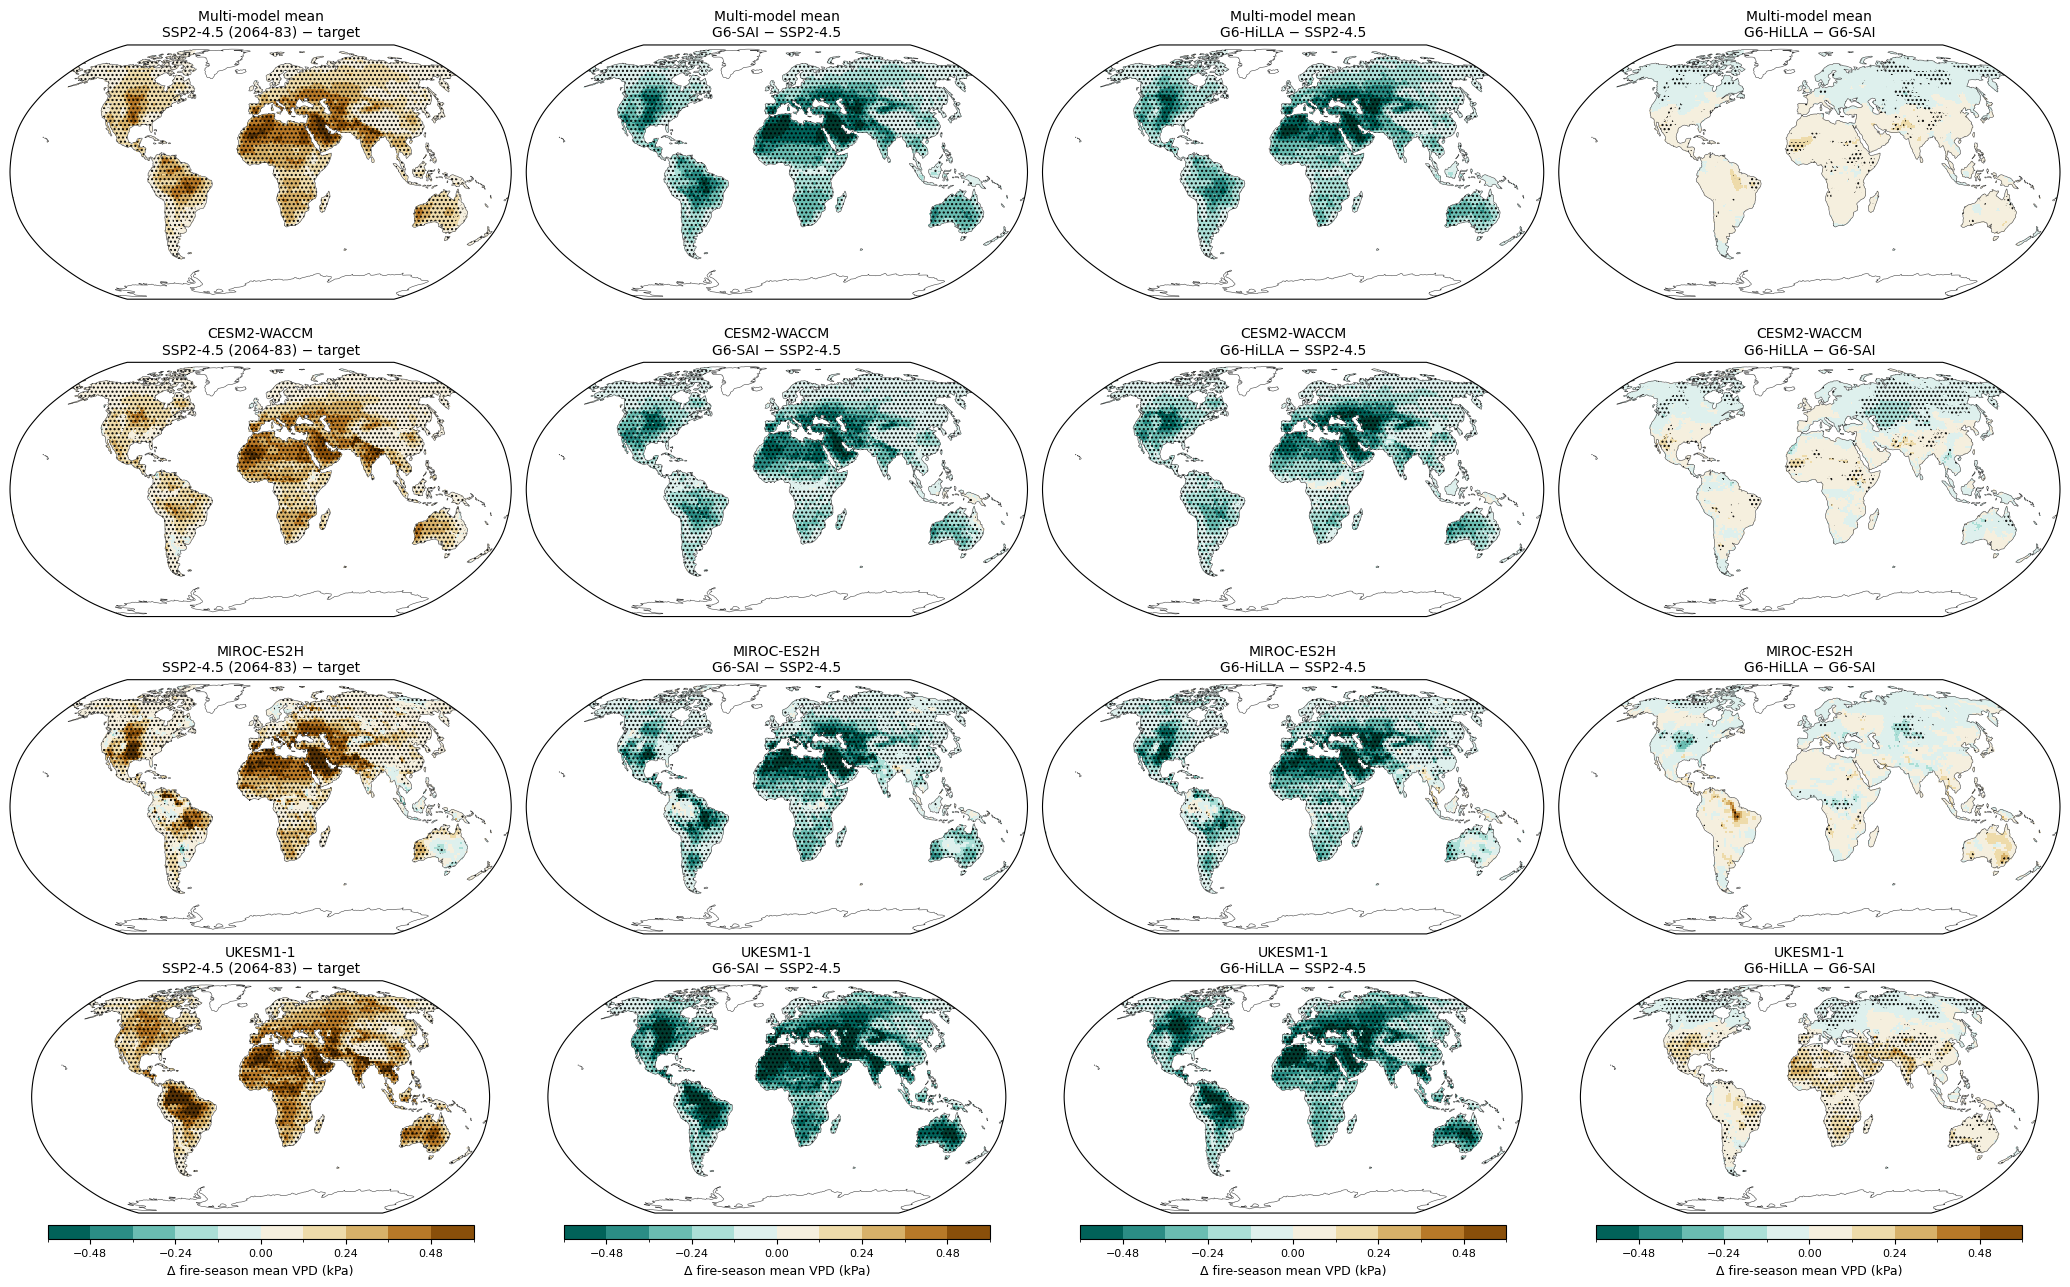

In [7]:
FIG_PAIRS = ["ssp245_minus_target", "SAI_minus_ssp245", "HiLLA_minus_ssp245", "HiLLA_minus_SAI"]

def delta_figure(key, label, fname, cmap, floor=None, per_model=True, pairs=FIG_PAIRS):
    panels = [("Multi-model mean" if len(models) > 1 else models[0], mm, mm_land, "robust_")]
    if per_model and len(models) > 1:
        panels += [(m, summary[m], summary[m]["land"], "sig_") for m in models]
    vlim = P.symmetric_limit(xr.concat([mm[f"d_{key}_{p}"].where(mm_land) for p in pairs], "p"), floor=floor)
    fig, axes = P.map_axes(len(panels), len(pairs))
    for i, (name, ds, land, sp) in enumerate(panels):
        for j, pair in enumerate(pairs):
            st = ds.get(f"{sp}{key}_{pair}")
            P.map_panel(axes[i, j], ds[f"d_{key}_{pair}"], cmap, -vlim, vlim, f"{name}\n{PAIR_TITLE[pair]}",
                        stipple=None if st is None else st.where(land, False), cbar_label=label, land=land,
                        cbar=(i == len(panels) - 1))
    fig.tight_layout(); P.save_figure(fig, f"{FIG_DIR}/{fname}", FIG_DPI); plt.show()

delta_figure("vpd_fs", "Δ fire-season mean VPD (kPa)", "fig7_delta_fireseason_vpd", "BrBG_r", floor=0.02)

### Figure 8 — Change in days per year above the P95 of VPD

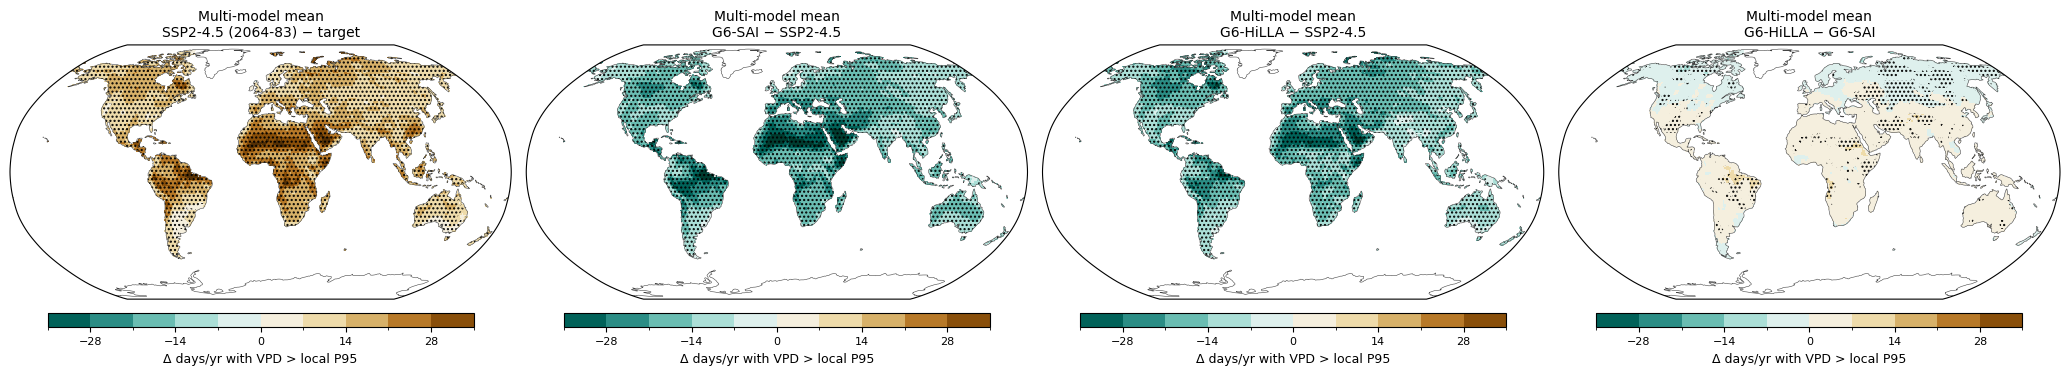

In [8]:
delta_figure("vpd_days_p95", "Δ days/yr with VPD > local P95", "fig8_delta_vpd_p95_days", "BrBG_r", floor=1, per_model=False)

### Figure 9 — Why does VPD change? Thermodynamic (cooling) and humidity terms, alongside precipitation
Multi-model mean. The temperature term shows how much lower saturation vapour pressure reduces demand. The RH term shows changes in the moisture supply to the air.

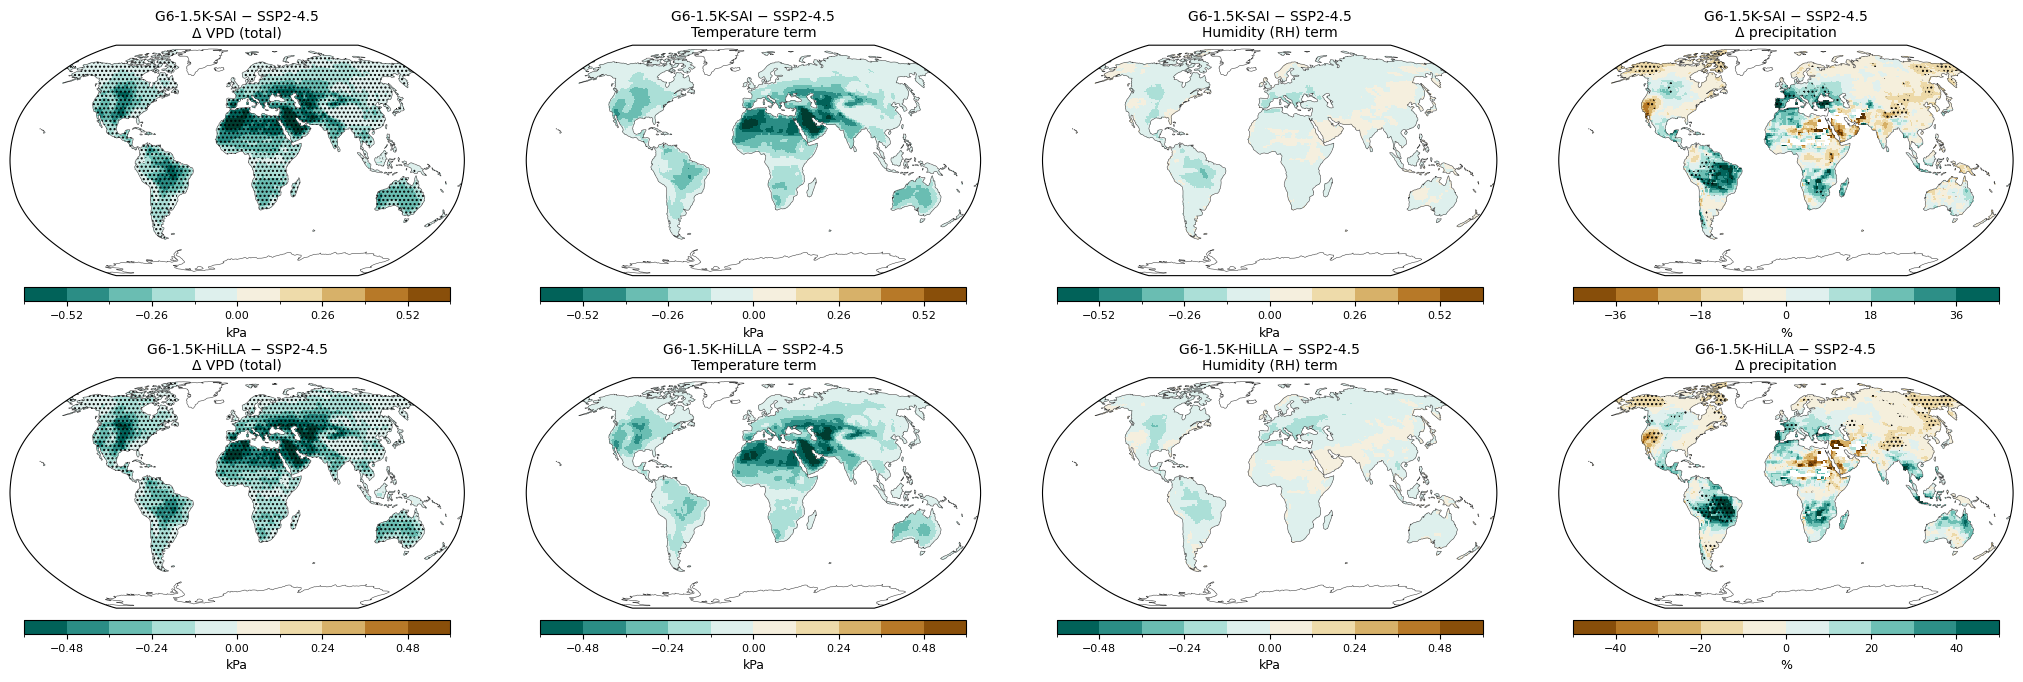

In [9]:
fig, axes = P.map_axes(2, 4)
for i, s in enumerate(G6):
    pair = SCEN_PAIR[s]
    fields = [(mm[f"d_vpd_fs_{pair}"], "Δ VPD (total)"), (mm[f"dvpd_fs_T_{s}"], "Temperature term"),
              (mm[f"dvpd_fs_RH_{s}"], "Humidity (RH) term")]
    vlim = P.symmetric_limit(xr.concat([f.where(mm_land) for f, _ in fields], "k"), floor=0.02)
    for j, (f, t) in enumerate(fields):
        P.map_panel(axes[i, j], f, "BrBG_r", -vlim, vlim, f"{P.SCEN_LABEL[s]} − SSP2-4.5\n{t}",
                    stipple=mm[f"robust_vpd_fs_{pair}"].where(mm_land, False) if j == 0 else None,
                    cbar_label="kPa", land=mm_land)
    plim = P.symmetric_limit(mm[f"dpct_pr_fs_{pair}"].where(mm_land), floor=2)
    P.map_panel(axes[i, 3], mm[f"dpct_pr_fs_{pair}"], "BrBG", -plim, plim, f"{P.SCEN_LABEL[s]} − SSP2-4.5\nΔ precipitation",
                stipple=mm[f"robust_pr_fs_{pair}"].where(mm_land, False), cbar_label="%", land=mm_land)
fig.tight_layout(); P.save_figure(fig, f"{FIG_DIR}/fig9_vpd_decomposition", FIG_DPI); plt.show()

### Figure 10 — Risk-offset zones: does cooling offset drying?
Classes combine the signs of Δ fire-season VPD, Δ precipitation and Δ FWI (Task 1). The *fire-weather paradox* class is also hatched, so it can be identified without relying on colour. The bars give the land-area fraction in each class; classes with no land area are left out of the legend and bars.

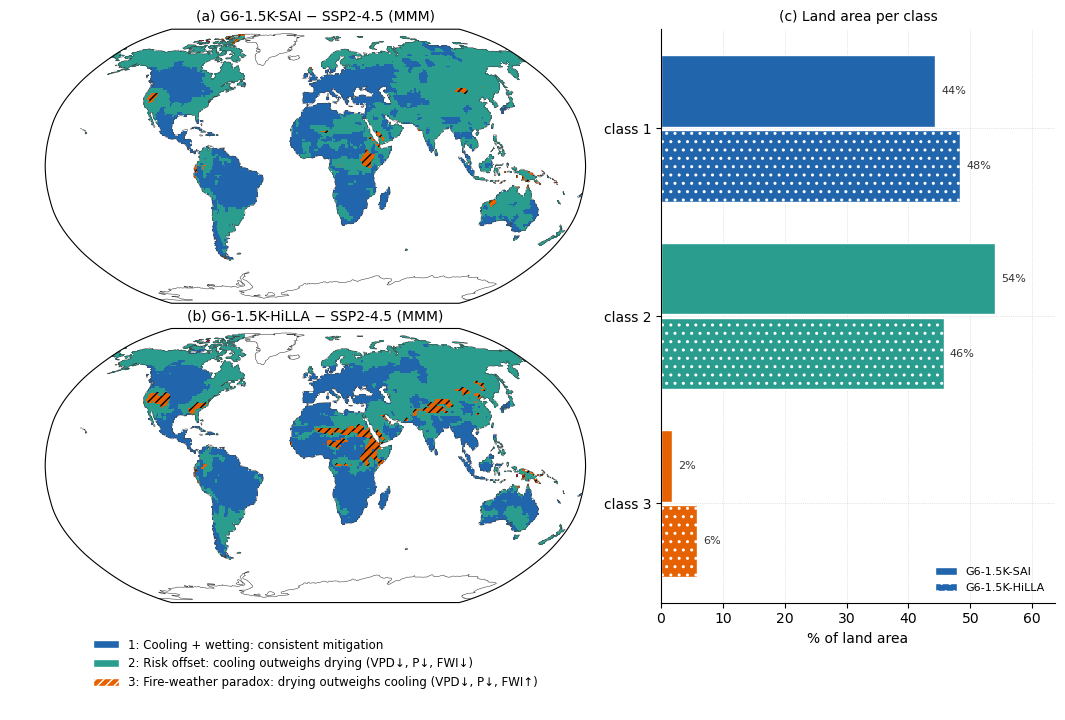

,G6-1.5K-SAI,G6-1.5K-HiLLA
Cooling + wetting: consistent mitigation,44.3,48.4
"Risk offset: cooling outweighs drying (VPD↓, P↓, FWI↓)",54.0,45.7
"Fire-weather paradox: drying outweighs cooling (VPD↓, P↓, FWI↑)",1.7,5.9
"Consistent exacerbation (VPD↑, P↓)",0.0,0.0
"Higher demand, wetter (VPD↑, P↑)",0.0,0.0


In [10]:
import cartopy.crs as ccrs
fracs = {P.SCEN_LABEL[s]: P.area_fractions(mm[f"offset_class_{s}"], mm_land) for s in G6}
fr = pd.DataFrame(fracs)
shown = [c for c in fr.index if (fr.loc[c] >= 0.0005).any()]     # classes with no land area are left out
fr_s = fr.loc[shown]
# layout: maps stacked in the left column, class legend directly under them, bars on the right
fig = plt.figure(figsize=(11, 7.4))
gs = fig.add_gridspec(3, 2, width_ratios=[1.55, 1], height_ratios=[1, 1, 0.30], wspace=0.08, hspace=0.12,
                      left=0.02, right=0.97, top=0.95, bottom=0.03)
for i, s in enumerate(G6):
    ax = fig.add_subplot(gs[i, 0], projection=ccrs.Robinson())
    P.class_map_panel(ax, mm[f"offset_class_{s}"], f"({'ab'[i]}) {P.SCEN_LABEL[s]} − SSP2-4.5 ({'MMM' if len(models) > 1 else models[0]})", mm_land)
axl = fig.add_subplot(gs[2, 0]); axl.axis("off")
handles = [mpatches.Patch(facecolor=P.OFFSET_CLASSES[k][1], hatch="////" if k == 3 else None, edgecolor="white",
                          label=f"{k}: {P.OFFSET_CLASSES[k][0]}") for k in shown]
axl.legend(handles=handles, loc="upper center", ncol=1, fontsize=8.5, frameon=False, handlelength=2.2)
axb = fig.add_subplot(gs[0:2, 1])
y = np.arange(len(fr_s))
for k, col in enumerate(fr_s.columns):
    yy = y + (k - 0.5) * 0.4
    axb.barh(yy, fr_s[col] * 100, height=0.38, color=[P.OFFSET_CLASSES[c][1] for c in fr_s.index],
             hatch=None if k == 0 else "..", edgecolor="white", label=col)
    for yv, v in zip(yy, fr_s[col] * 100):
        axb.text(v + 1, yv, f"{v:.0f}%", va="center", fontsize=8, color="#333333")
axb.set_yticks(y, [f"class {c}" for c in fr_s.index]); axb.invert_yaxis()
axb.set_xlim(0, max(10, float(fr_s.max().max()) * 100 * 1.18))
axb.set_xlabel("% of land area"); P.style_axes(axb)
axb.set_title("(c) Land area per class", fontsize=10)
axb.legend(fontsize=8, frameon=False, loc="lower right")
P.save_figure(fig, f"{FIG_DIR}/fig10_risk_offset_zones", FIG_DPI); plt.show()
display((fr * 100).round(1).rename(index={k: v[0] for k, v in P.OFFSET_CLASSES.items()}))

## 4. AR6 regional statistics and Figure 11 — regional VPD decomposition

quantity,vpd_fs_target,vpd_fs_ssp245,d_vpd_fs_SAI_minus_ssp245,dvpd_fs_T_G6-1.5K-SAI,dvpd_fs_RH_G6-1.5K-SAI,dpct_pr_fs_SAI_minus_ssp245,d_vpd_fs_HiLLA_minus_ssp245,dvpd_fs_T_G6-1.5K-HiLLA,dvpd_fs_RH_G6-1.5K-HiLLA,dpct_pr_fs_HiLLA_minus_ssp245
region,,,,,,,,,,
NWN,0.453,0.573,-0.118,-0.082,-0.028,-3.205,-0.141,-0.096,-0.043,-3.454
NEN,0.418,0.544,-0.133,-0.087,-0.043,-4.129,-0.148,-0.096,-0.052,-3.760
WSB,1.453,1.714,-0.294,-0.230,-0.047,-1.740,-0.352,-0.276,-0.074,-1.759
ESB,0.681,0.808,-0.133,-0.110,-0.007,-5.474,-0.152,-0.122,-0.023,-6.656
WNA,1.673,1.852,-0.277,-0.234,-0.032,-7.971,-0.276,-0.241,-0.032,-9.901
MED,2.525,2.901,-0.469,-0.360,-0.108,29.665,-0.443,-0.351,-0.099,20.041
NSA,1.658,1.954,-0.322,-0.200,-0.120,15.823,-0.261,-0.165,-0.102,17.521
SAM,1.774,2.100,-0.390,-0.237,-0.156,32.524,-0.327,-0.193,-0.144,41.369
NES,2.014,2.274,-0.323,-0.211,-0.115,36.270,-0.249,-0.170,-0.085,37.963


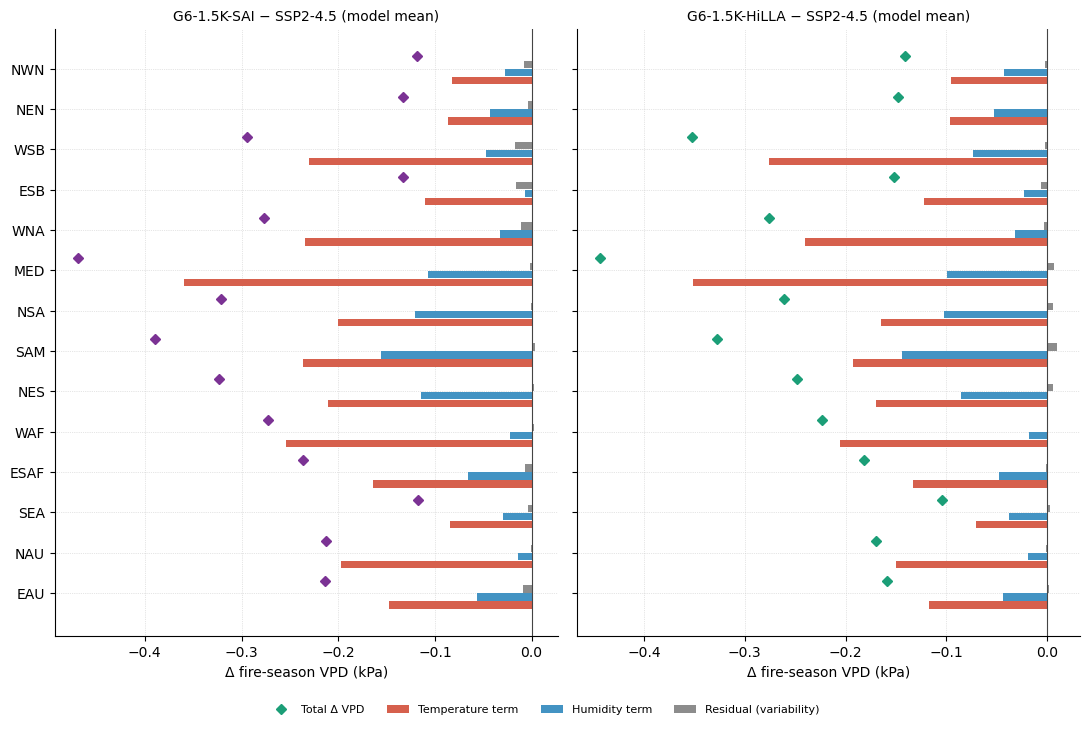

In [11]:
recs = []
for m in models:
    s_ = summary[m]
    keys = [k for k in s_.data_vars if (k.startswith(("vpd_fs_", "pr_fs_", "vpd_days_p95_", "d_", "dpct_", "dvpd_fs_"))
                                        and set(s_[k].dims) == {"lat", "lon"})]
    for k in keys:
        r = P.regional_means(s_[k].astype(float))
        for reg in r.region.values:
            recs.append(dict(model=m, quantity=k, region=str(reg), region_name=str(r.sel(region=reg).region_name.values),
                             value=float(r.sel(region=reg))))
reg2 = pd.DataFrame(recs); reg2.to_csv(f"{OUT_DIR}/task2_AR6_regional_stats.csv", index=False)
tab = reg2[reg2.region.isin(FOCUS_REGIONS)].pivot_table(index="region", columns="quantity", values="value", aggfunc="mean")
cols = ["vpd_fs_target", "vpd_fs_ssp245", "d_vpd_fs_SAI_minus_ssp245", "dvpd_fs_T_G6-1.5K-SAI", "dvpd_fs_RH_G6-1.5K-SAI",
        "dpct_pr_fs_SAI_minus_ssp245", "d_vpd_fs_HiLLA_minus_ssp245", "dvpd_fs_T_G6-1.5K-HiLLA",
        "dvpd_fs_RH_G6-1.5K-HiLLA", "dpct_pr_fs_HiLLA_minus_ssp245"]
display(tab.reindex(FOCUS_REGIONS)[cols].round(3))

TERM_COL = {"Temperature term": "#d6604d", "Humidity term": "#4393c3", "Residual (variability)": "#8c8c8c"}
fig, axes = plt.subplots(1, 2, figsize=(11, 0.4 * len(FOCUS_REGIONS) + 1.4), sharey=True)
for ax, s in zip(axes, G6):
    pair = SCEN_PAIR[s]
    terms = {"Temperature term": f"dvpd_fs_T_{s}", "Humidity term": f"dvpd_fs_RH_{s}", "Residual (variability)": f"dvpd_fs_resid_{s}"}
    regs = [r for r in FOCUS_REGIONS if r in tab.index][::-1]
    h = 0.8 / (len(terms) + 1)
    for k, (lab, key) in enumerate(terms.items()):
        yy = np.arange(len(regs)) + (k - len(terms) / 2) * h
        ax.barh(yy, tab.reindex(regs)[key], height=h * 0.9, color=TERM_COL[lab], label=lab)
    ax.plot(tab.reindex(regs)[f"d_vpd_fs_{pair}"], np.arange(len(regs)) + (len(terms) / 2) * h, "D",
            color=P.SCEN_STYLE[s]["color"], ms=5, label="Total Δ VPD", zorder=4)
    ax.axvline(0, color="#444444", lw=0.8); ax.set_yticks(np.arange(len(regs)), regs)
    ax.set_title(f"{P.SCEN_LABEL[s]} − SSP2-4.5 (model mean)", fontsize=10); ax.set_xlabel("Δ fire-season VPD (kPa)")
    P.style_axes(ax)
h_, l_ = axes[1].get_legend_handles_labels()
fig.legend(h_, l_, fontsize=8, frameon=False, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=len(l_))
fig.tight_layout(); P.save_figure(fig, f"{FIG_DIR}/fig11_regional_vpd_decomposition", FIG_DPI); plt.show()

## 5. Outputs
| file | content |
|---|---|
| `task2_<model>_summary.nc` | fire-season VPD and precipitation, P95-VPD days and spells, all deltas with FDR masks, T/RH decomposition, risk-offset classes |
| `task2_multimodel_1deg.nc` | multi-model fields on the 1° atlas grid |
| `task2_AR6_regional_stats.csv` | all AR6 land regions |
| `figures/fig7`–`fig11` | report figures |

**Methods text (draft):** *Daily vapour pressure deficit was computed from daily-mean near-surface air temperature and relative humidity, using the Sonntag (1990) saturation vapour pressure over water. Fire-season means use each grid cell's three consecutive months of highest target-period FWI. The G6 − SSP2-4.5 change in fire-season VPD was decomposed with a delta approach. SSP2-4.5 daily temperature (or relative humidity) was perturbed by the monthly climatological change simulated under G6, holding the other variable fixed. The residual reflects changes in daily covariability and nonlinearity.*

In [12]:
for f in sorted(os.listdir(FIG_DIR)):
    print("  ", f)

   fig10_risk_offset_zones.pdf
   fig10_risk_offset_zones.png
   fig11_regional_vpd_decomposition.pdf
   fig11_regional_vpd_decomposition.png
   fig1_delta_p95_days.png
   fig2_delta_fireseason_fwi.png
   fig3a_delta_spell.png
   fig3b_delta_abs_days.png
   fig4_regional_delta_p95_days.png
   fig5_seasonality_CESM2-WACCM.png
   fig5_seasonality_MIROC-ES2H.png
   fig5_seasonality_UKESM1-1.png
   fig7_delta_fireseason_vpd.pdf
   fig7_delta_fireseason_vpd.png
   fig8_delta_vpd_p95_days.pdf
   fig8_delta_vpd_p95_days.png
   fig9_vpd_decomposition.pdf
   fig9_vpd_decomposition.png
   figS1_context.png
